# Preparación de datos - data_prep.csv

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
data_path = 'Data'

In [13]:
student_data = pd.read_csv(os.path.join(data_path, 'student_data.csv'))
attempts_data = pd.read_csv(os.path.join(data_path, 'attempts.csv'))

In [14]:
# ¿Cuántos casos hay con más de 300 segundos?
casos_mayores_300 = (attempts_data['durationseconds'] > 300).sum()
print(f"¿Cuántos casos hay con más de 300 segundos?: {casos_mayores_300} casos.")

# Limitar a 300 los valores atípicos
attempts_data['durationseconds'] = np.where(
    attempts_data['durationseconds'] > 300, 300, attempts_data['durationseconds']
)

¿Cuántos casos hay con más de 300 segundos?: 217 casos.


In [15]:
# 1. total_time: suma de durationseconds por estudiante
total_time = attempts_data.groupby('student')['durationseconds'].sum().rename('total_time')

# 2. total_activity: conteo total de filas por estudiante
total_activity = attempts_data.groupby('student').size().rename('total_activity')

# 3. qp_activity: conteo de filas donde applabel es QUIZPET o PARSONS
qp_activity = (
    attempts_data[attempts_data['applabel'].isin(['QUIZPET', 'PARSONS'])]
    .groupby('student').size().rename('qp_activity')
)

# 4. total_activity_be: conteo de filas donde relativetime < 5600000
total_activity_be = (
    attempts_data[attempts_data['relativetime'] < 5600000]
    .groupby('student').size().rename('total_activity_be')
)

# Consolidar en un solo DataFrame
engagement_df = pd.concat(
    [total_time, total_activity, qp_activity, total_activity_be], axis=1
).fillna(0).reset_index()

In [16]:
# Asegurar tipos numéricos
for col in ['exam', 'pretest', 'posttest']:
    student_data[col] = pd.to_numeric(student_data[col], errors='coerce')

# exam_norm: exam / 100
student_data['exam_norm'] = student_data['exam'] / 100.0

# lgain_pp: (posttest - pretest) / (1 - pretest)
student_data['lgain_pp'] = (
    (student_data['posttest'] - student_data['pretest']) /
    (1 - student_data['pretest'])
)

# lgain_pe: (exam_norm - pretest) / (1 - pretest)
student_data['lgain_pe'] = (
    (student_data['exam_norm'] - student_data['pretest']) /
    (1 - student_data['pretest'])
)

In [17]:
# Unir datos de estudiantes con features de engagement
data_prep = pd.merge(student_data, engagement_df, on='student', how='left')

# Rellenar con 0 los estudiantes sin actividad registrada
engagement_cols = ['total_time', 'total_activity', 'qp_activity', 'total_activity_be']
data_prep[engagement_cols] = data_prep[engagement_cols].fillna(0)

# Seleccionar y ordenar columnas según la pauta
columnas_finales = [
    'student', 'social', 'gender', 'take_exam',
    'Fi', 'CBi', 'Vi', 'MApi', 'PApi',
    'total_time', 'total_activity', 'qp_activity', 'total_activity_be',
    'pretest', 'posttest', 'exam_norm', 'lgain_pp', 'lgain_pe'
]

data_prep = data_prep[columnas_finales]

In [18]:
output_path = os.path.join(data_path, 'data_prep.csv')
data_prep.to_csv(output_path, index=False)

print(f"Archivo guardado: {output_path}")
print(f"Registros: {len(data_prep)}, Columnas: {len(data_prep.columns)}")
print(f"Columnas: {list(data_prep.columns)}")

Archivo guardado: Data\data_prep.csv
Registros: 685, Columnas: 18
Columnas: ['student', 'social', 'gender', 'take_exam', 'Fi', 'CBi', 'Vi', 'MApi', 'PApi', 'total_time', 'total_activity', 'qp_activity', 'total_activity_be', 'pretest', 'posttest', 'exam_norm', 'lgain_pp', 'lgain_pe']


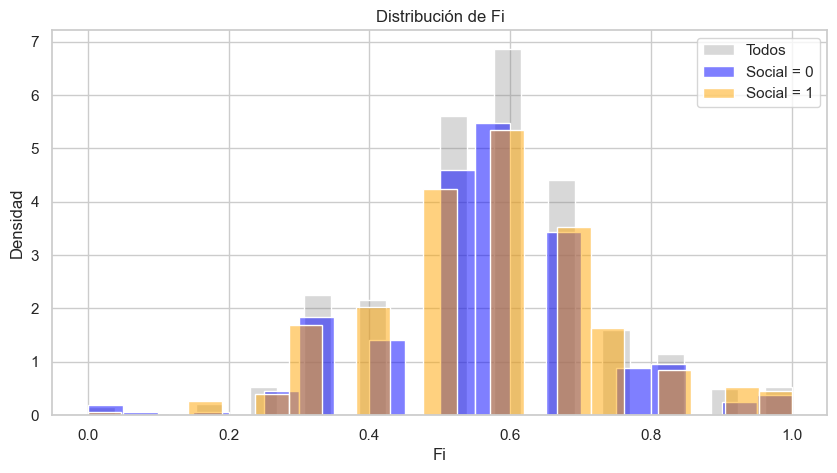

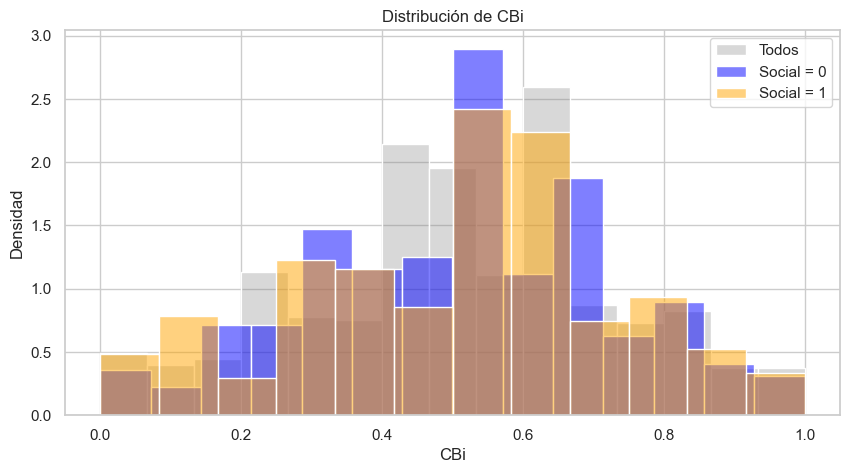

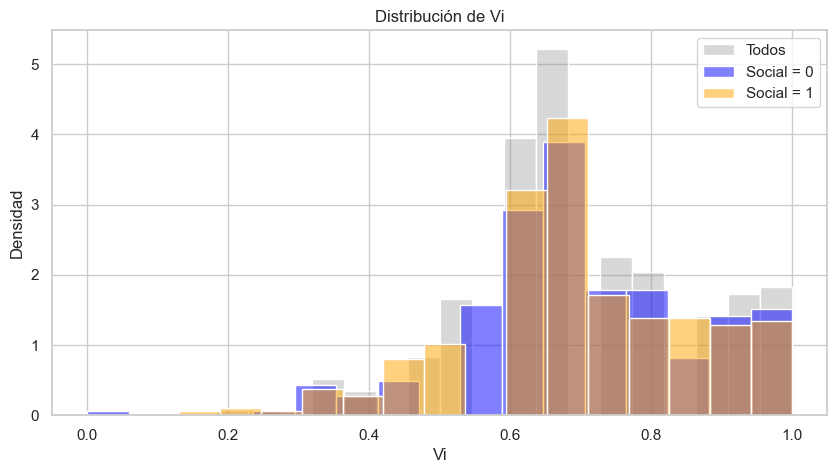

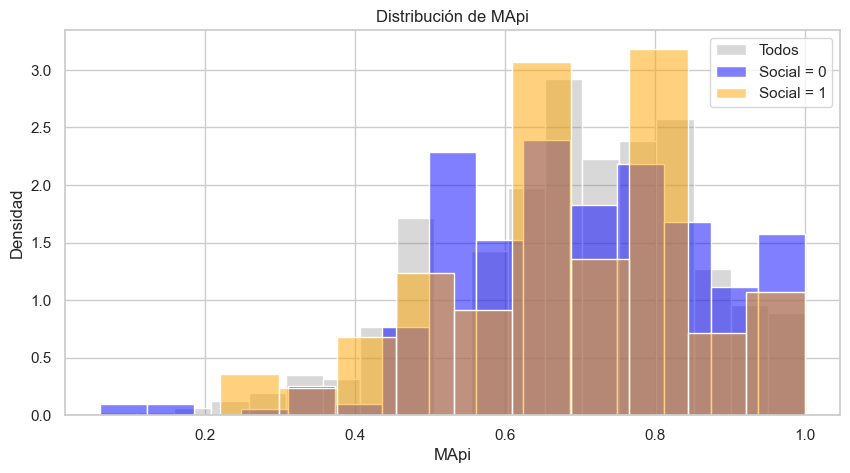

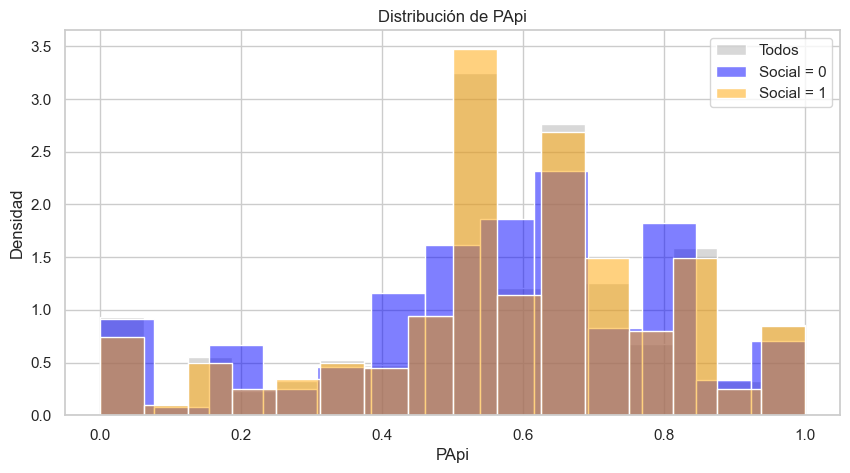

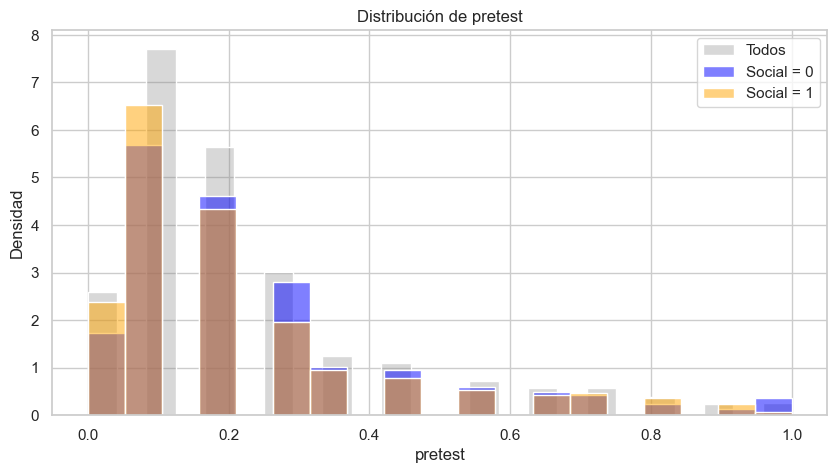

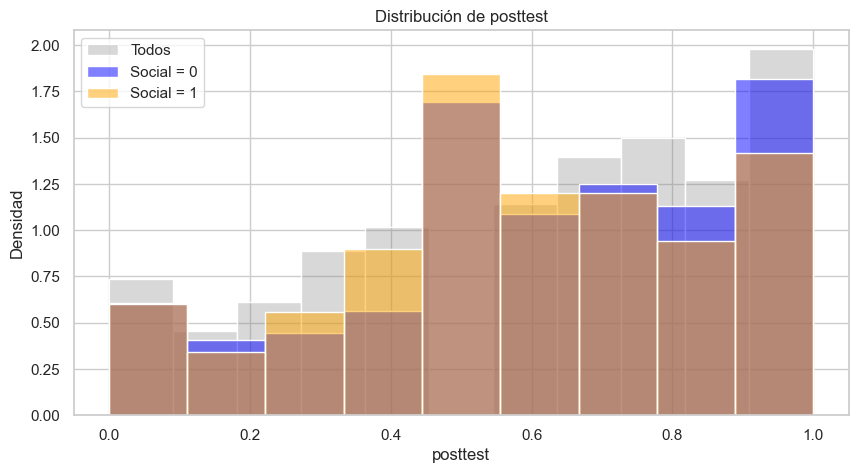

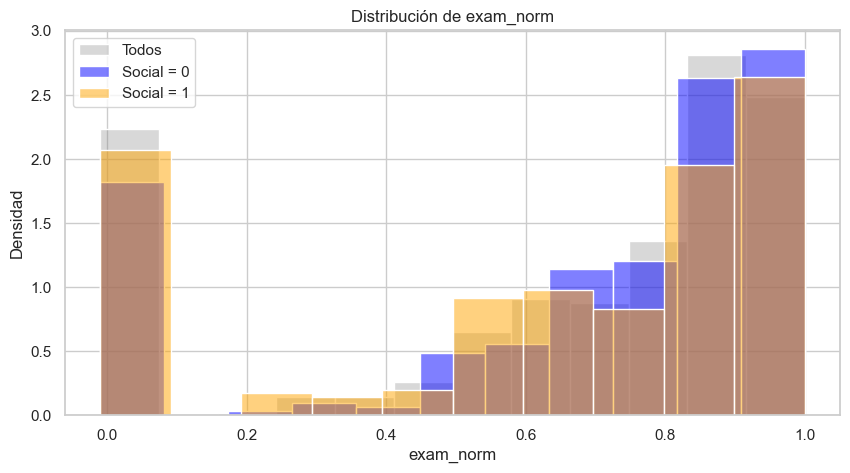

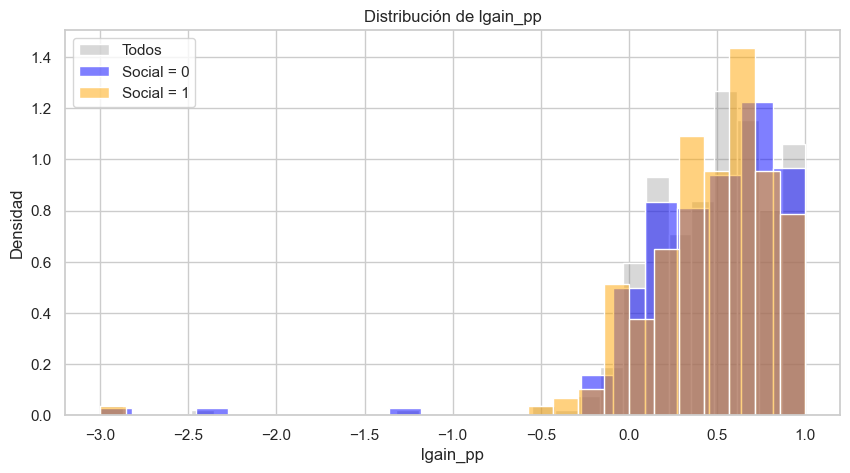

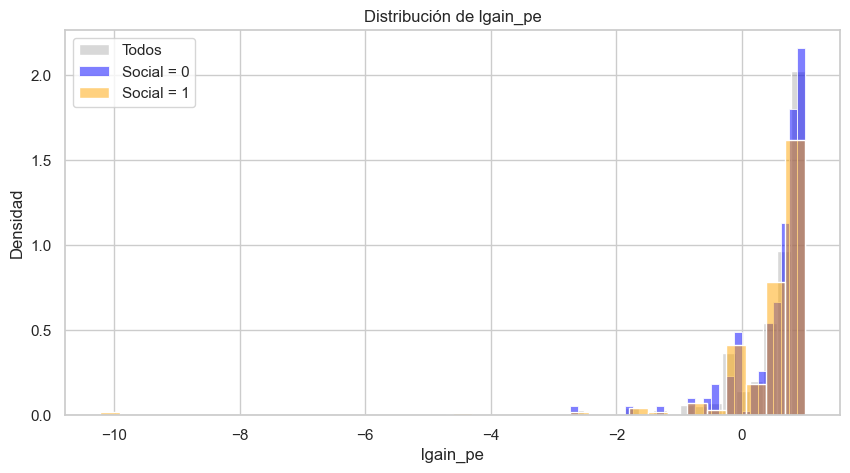

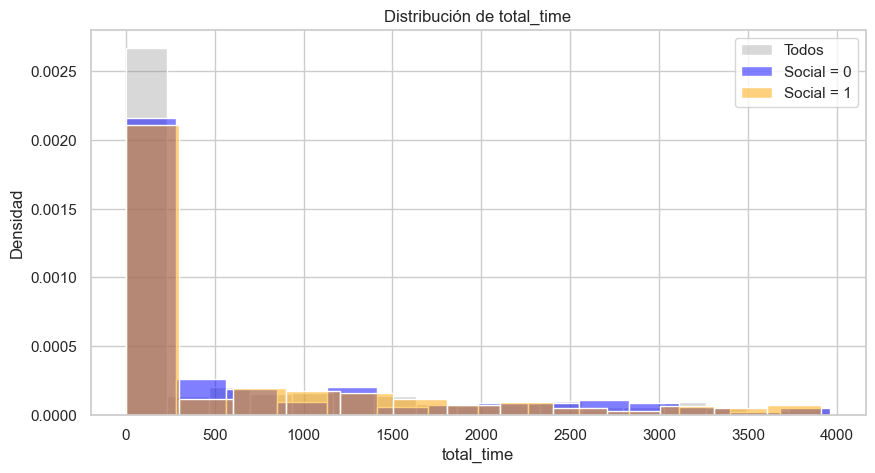

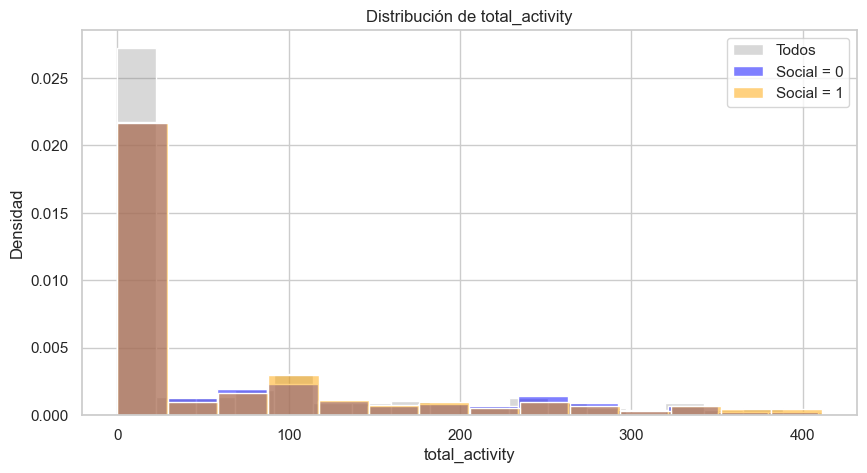

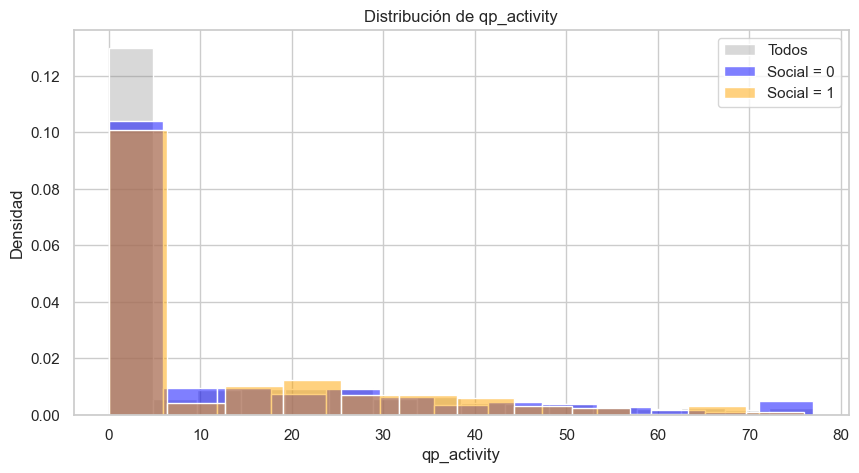

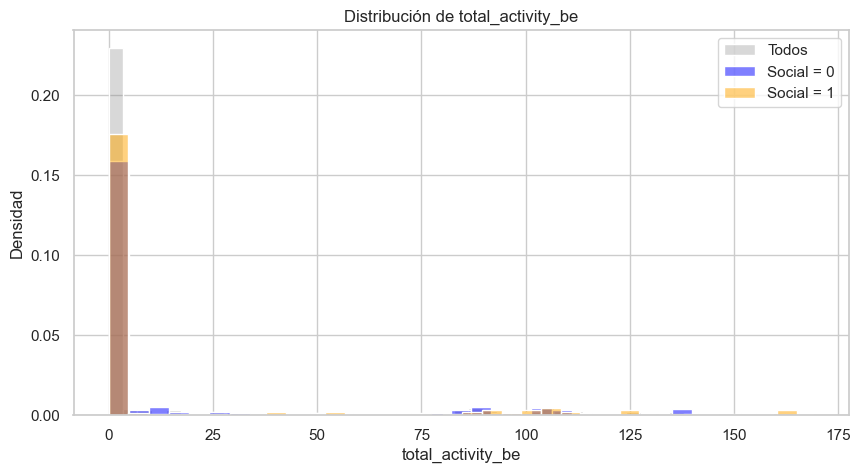

Gráficos guardados en: Data\figuras


In [21]:
import os

# Carpeta de salida para los gráficos
figuras_path = os.path.join(data_path, 'figuras')
os.makedirs(figuras_path, exist_ok=True)

def plot_distribution(df, column, is_engagement=False):
    # Asegurar que la columna sea numérica
    data_to_plot = df.copy()
    data_to_plot[column] = pd.to_numeric(data_to_plot[column], errors='coerce')
    data_to_plot = data_to_plot.dropna(subset=[column])

    # Filtrar outliers (IQR) si es variable de engagement
    if is_engagement:
        Q1 = data_to_plot[column].quantile(0.25)
        Q3 = data_to_plot[column].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        data_to_plot = data_to_plot[data_to_plot[column] <= upper_bound]

    fig, ax = plt.subplots(figsize=(10, 5))
    # Histogramas superpuestos: total + por grupo social
    sns.histplot(data=data_to_plot, x=column, label='Todos', color='grey', alpha=0.3, ax=ax, stat='density')
    sns.histplot(data=data_to_plot[data_to_plot['social'] == 0], x=column, label='Social = 0', color='blue', alpha=0.5, ax=ax, stat='density')
    sns.histplot(data=data_to_plot[data_to_plot['social'] == 1], x=column, label='Social = 1', color='orange', alpha=0.5, ax=ax, stat='density')

    ax.set_title(f'Distribución de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Densidad')
    ax.legend()

    # Guardar como PNG
    filename = f'dist_{column}.png'
    fig.savefig(os.path.join(figuras_path, filename), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

vars_motivacionales = ['Fi', 'CBi', 'Vi', 'MApi', 'PApi']
vars_learning = ['pretest', 'posttest', 'exam_norm', 'lgain_pp', 'lgain_pe']
vars_engagement = ['total_time', 'total_activity', 'qp_activity', 'total_activity_be']

for var in vars_motivacionales + vars_learning:
    plot_distribution(data_prep, var, is_engagement=False)

for var in vars_engagement:
    plot_distribution(data_prep, var, is_engagement=True)

print(f"Gráficos guardados en: {figuras_path}")

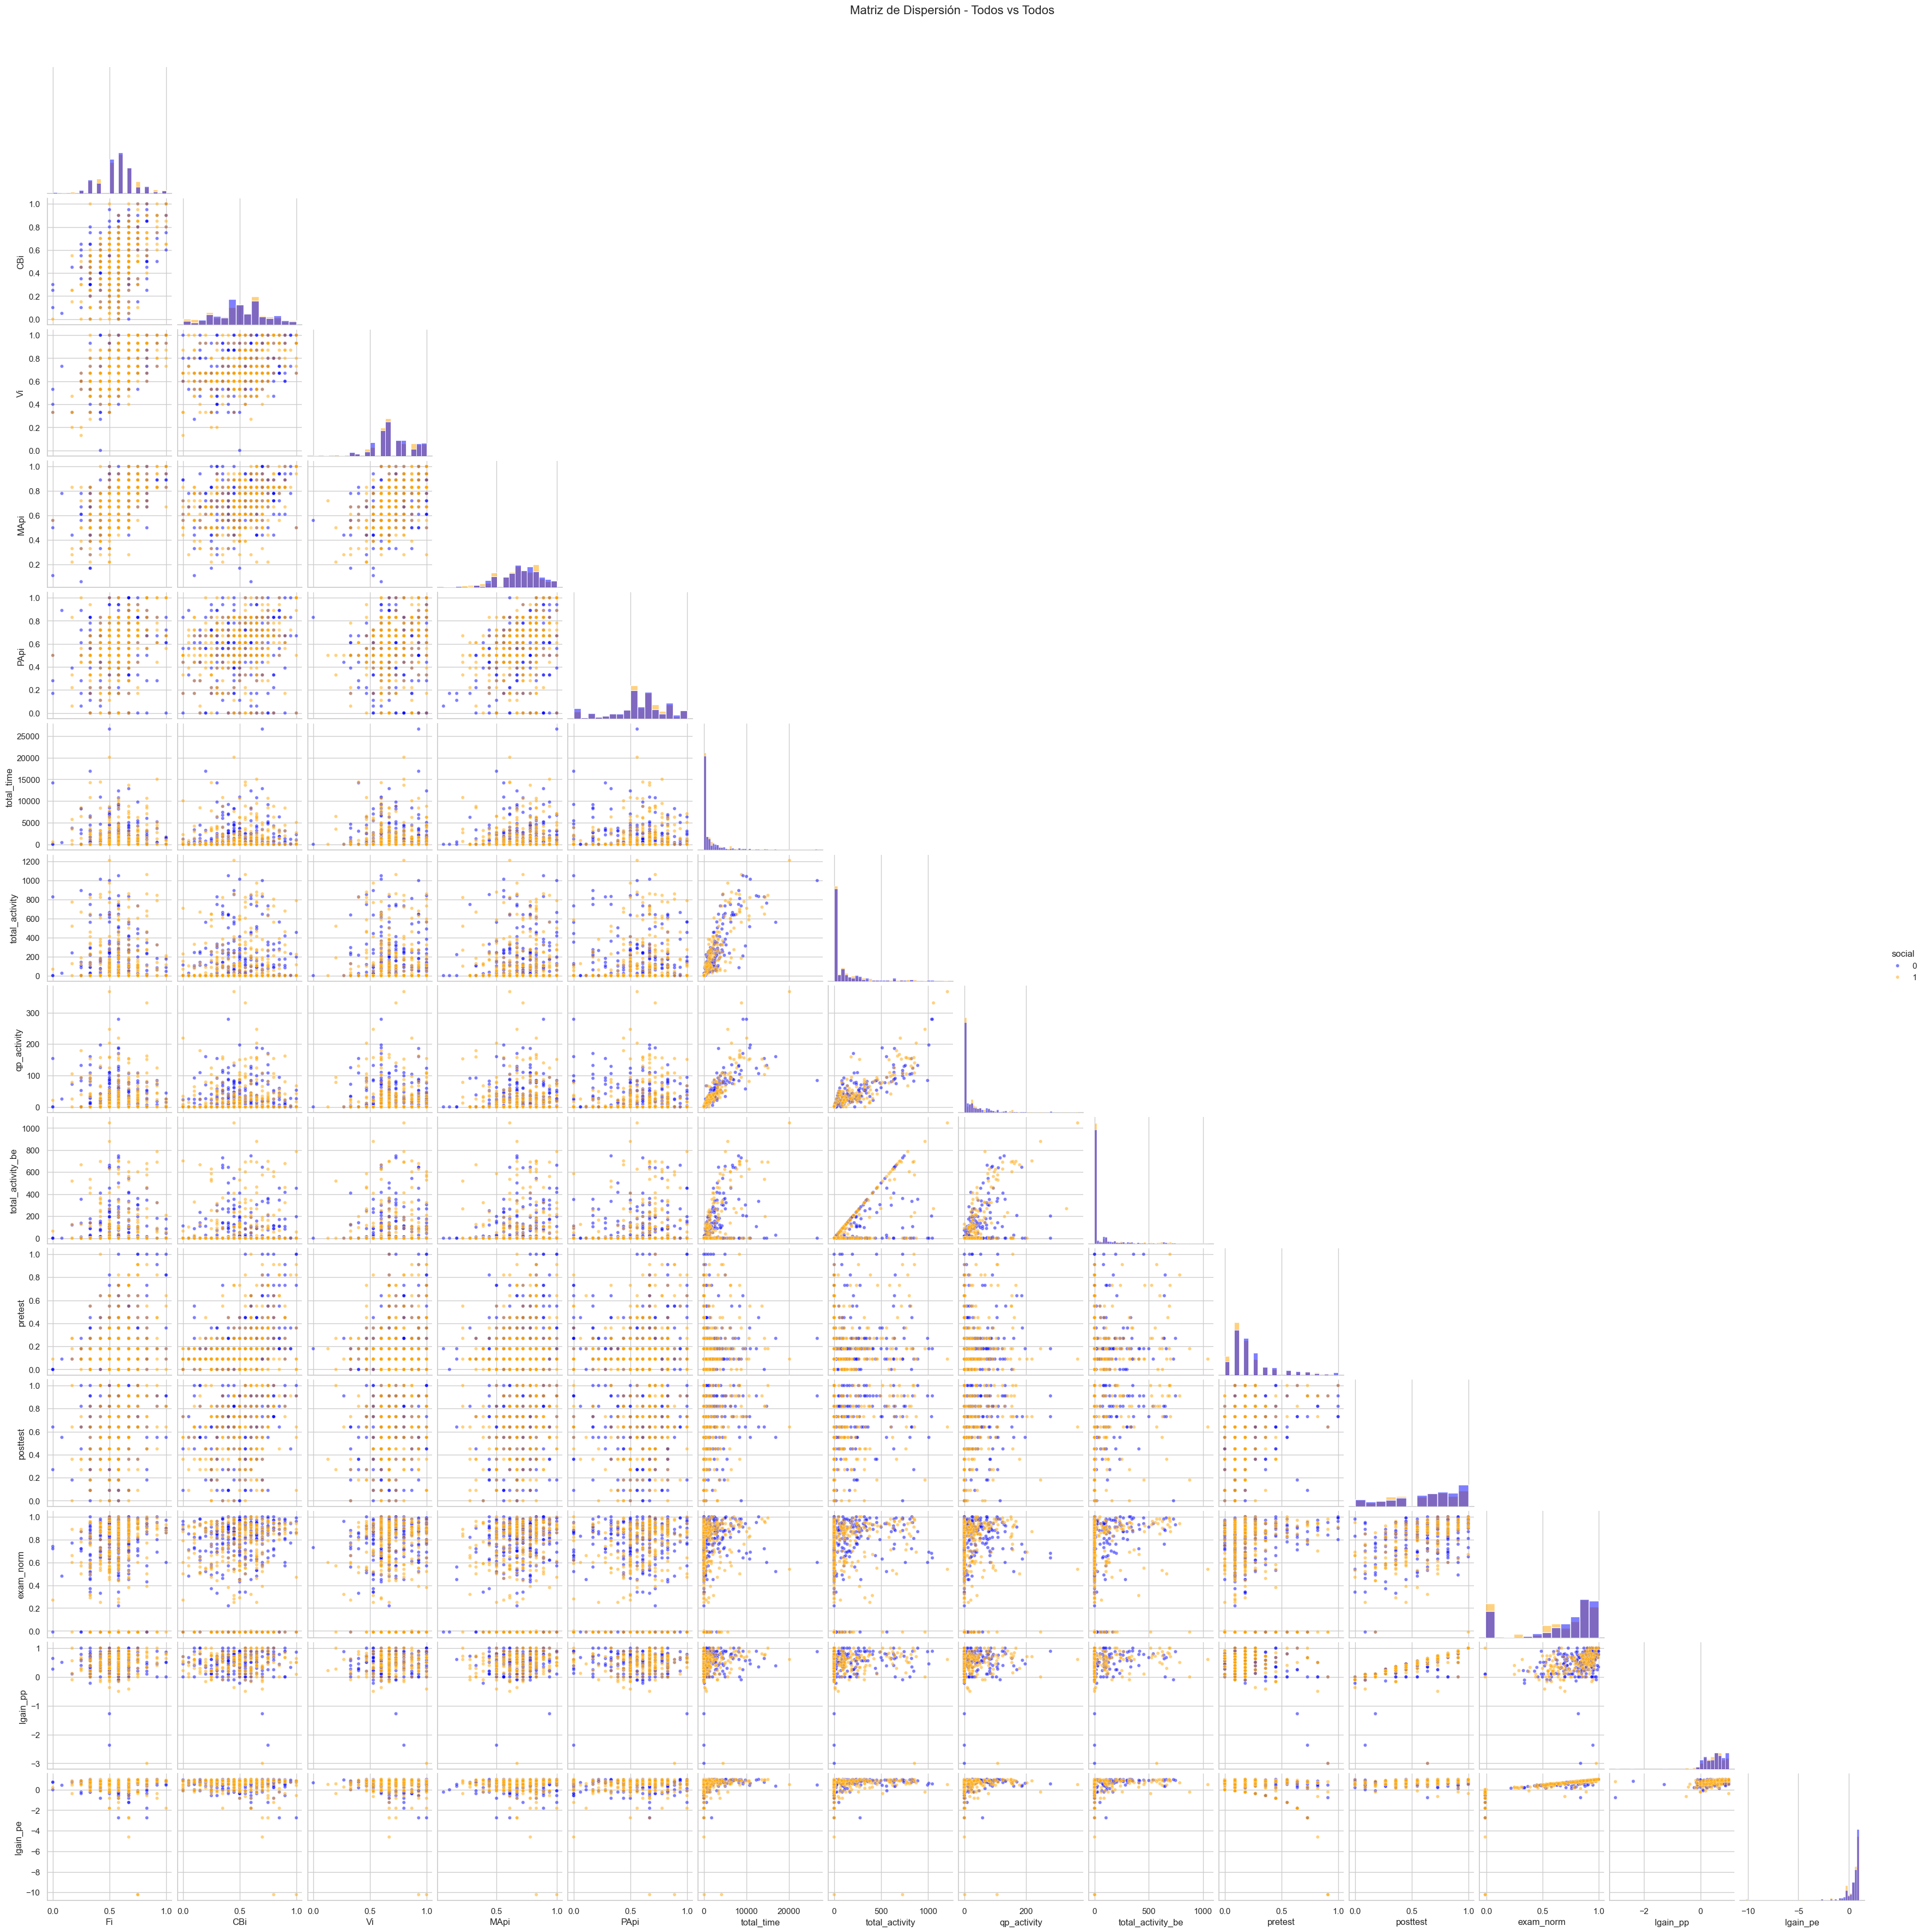

Pairplot guardado en: Data\figuras\pairplot_todos_vs_todos.png


In [22]:
# Scatter plot matrix: todos contra todos, coloreado por grupo social
vars_pairplot = ['Fi', 'CBi', 'Vi', 'MApi', 'PApi',
                 'total_time', 'total_activity', 'qp_activity', 'total_activity_be',
                 'pretest', 'posttest', 'exam_norm', 'lgain_pp', 'lgain_pe']

# Asegurar que todas las columnas sean numéricas
pairplot_data = data_prep.copy()
for col in vars_pairplot:
    pairplot_data[col] = pd.to_numeric(pairplot_data[col], errors='coerce')

# Crear el pairplot coloreando por grupo social
pairplot_fig = sns.pairplot(
    pairplot_data,
    vars=vars_pairplot,
    hue='social',
    palette={0: 'blue', 1: 'orange'},
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='hist',
    corner=True
)

pairplot_fig.fig.suptitle('Matriz de Dispersión - Todos vs Todos', y=1.02, fontsize=16)

# Guardar como PNG
pairplot_path = os.path.join(figuras_path, 'pairplot_todos_vs_todos.png')
pairplot_fig.savefig(pairplot_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"Pairplot guardado en: {pairplot_path}")